# Phase 1 - Setup the Project

**Step 1: checking T4 GPU**

In [ ]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


**Step 2: Mount Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Step 3: Go to your project folder and Check files**

In [ ]:
import os
project_path = "/content/drive/My Drive/Computer Vision Project"
os.chdir(project_path)
print(os.getcwd())
os.listdir()

/content/drive/My Drive/Computer Vision Project


['Dataset', 'yolo11n.pt', 'yolo26n.pt', 'Marine_Debris_YOLO', 'Project.ipynb']

# Phase 2 - Dataset Analysis

DATASET INFORMATION

Dataset Path:
/content/drive/My Drive/Computer Vision Project

Folder Structure:

Computer Vision Project/
    yolo11n.pt
    yolo26n.pt
    Project.ipynb
    Dataset/
        marine debris images dataset/
            README.roboflow.txt
            README.dataset.txt
            train/
                IMG_0034_JPG.rf.ccfb898b22e1df47ff11f0f91b5d5499.jpg
                IMG_0037_JPG.rf.500e36ebd177e069553bb0df3b9fab78.jpg
                IMG_0038_JPG.rf.806bf0d58fb3b2323c95cdf68586fbbb.jpg
                IMG_0035_JPG.rf.01e7d05d645440e8e1c63205e5823994.jpg
                IMG_0036_JPG.rf.acd72953574c5b0eb7a33f1bb8b6e3df.jpg
            valid/
                marine-debris-188-_jpg.rf.ba10aea7ae479d126de21e9bb4dff6d3.jpg
                _classes.csv
                marine-debris-185-_jpg.rf.6ffd87a3ec3058d9353b1be3dafdb566.jpg
                marine-debris-200-_jpg.rf.227cedeee9b8dc55ccebacaabc54db57.jpg
                marine-debris-202-_jpg.rf.b48122c9ed5589565e4

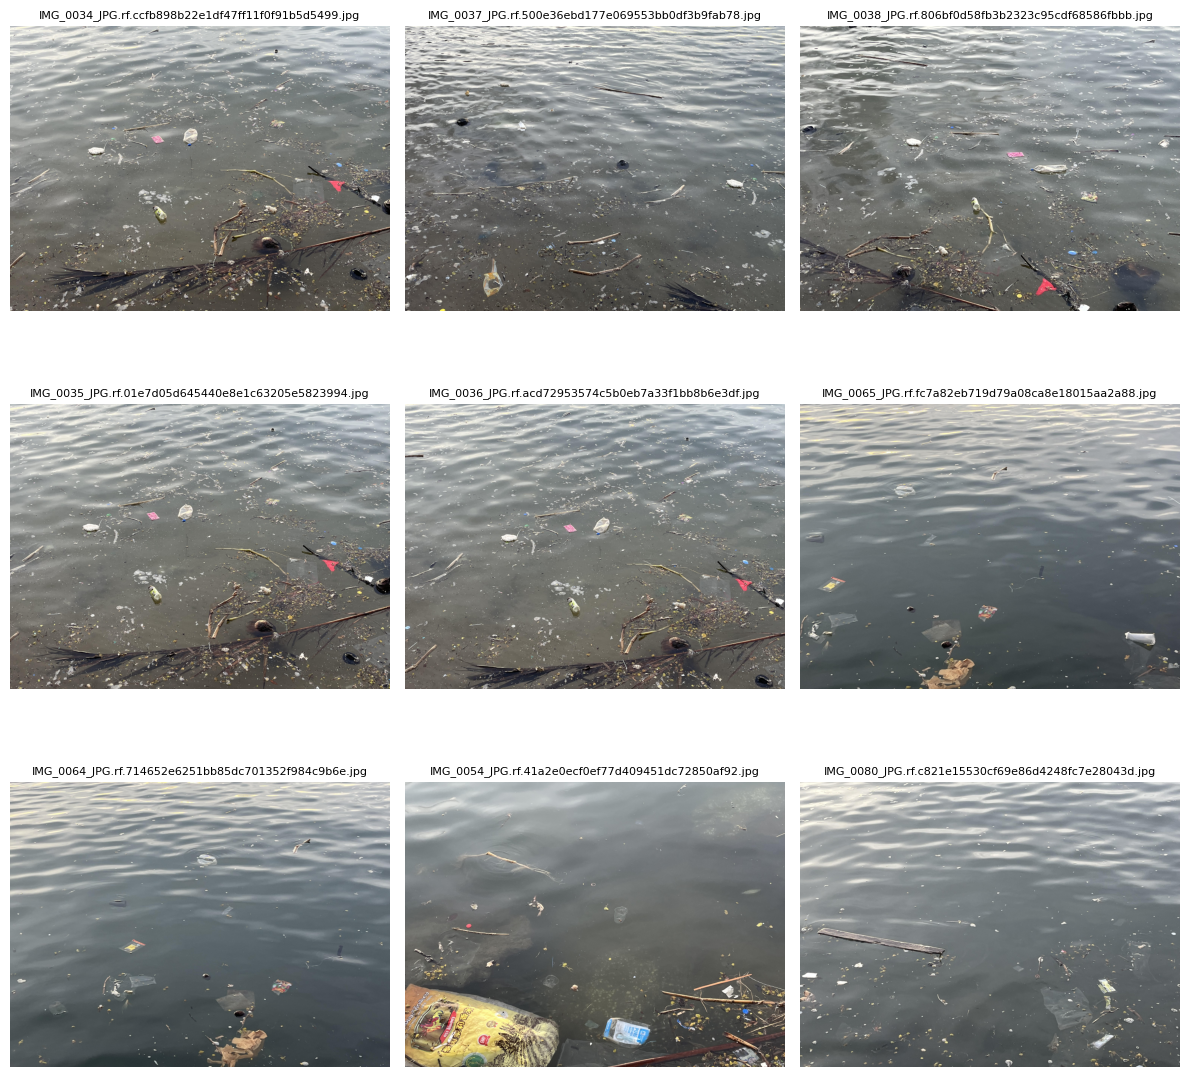


SUMMARY
                Property  Value
0           Total Images   1725
1          Image Formats      1
2  Different Resolutions     17
3       Corrupted Images      0
4  JSON Annotation Files      2


In [ ]:
import os
import json
from PIL import Image
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd

# ==========================================================
# CHANGE THIS PATH IF NECESSARY
# ==========================================================
DATASET_PATH = "/content/drive/My Drive/Computer Vision Project"

# ==========================================================
# BASIC INFORMATION
# ==========================================================

print("="*70)
print("DATASET INFORMATION")
print("="*70)

print(f"\nDataset Path:\n{DATASET_PATH}")

print("\nFolder Structure:\n")

for root, dirs, files in os.walk(DATASET_PATH):
    level = root.replace(DATASET_PATH, '').count(os.sep)
    indent = ' ' * 4 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = ' ' * 4 * (level + 1)
    for f in files[:5]:
        print(f"{subindent}{f}")

# ==========================================================
# IMAGE INFORMATION
# ==========================================================

image_extensions = (".jpg", ".jpeg", ".png", ".bmp")

image_paths = []

for root, dirs, files in os.walk(DATASET_PATH):
    for file in files:
        if file.lower().endswith(image_extensions):
            image_paths.append(os.path.join(root, file))

print("\n" + "="*70)
print("IMAGE INFORMATION")
print("="*70)

print(f"Total Images : {len(image_paths)}")

# Image formats
formats = Counter()

# Image sizes
resolutions = Counter()

corrupted = []

for img_path in image_paths:

    try:
        img = Image.open(img_path)

        formats[img.format] += 1

        resolutions[f"{img.width}x{img.height}"] += 1

    except:
        corrupted.append(img_path)

print("\nImage Formats")

for k,v in formats.items():
    print(f"{k:10} {v}")

print("\nTop 10 Image Resolutions")

for res,count in resolutions.most_common(10):
    print(f"{res:15} {count}")

print("\nCorrupted Images :", len(corrupted))

# ==========================================================
# FILE SIZE
# ==========================================================

sizes = []

for img in image_paths:
    sizes.append(os.path.getsize(img)/(1024*1024))

print("\nAverage Image Size : %.2f MB"%(sum(sizes)/len(sizes)))
print("Smallest Image     : %.2f MB"%(min(sizes)))
print("Largest Image      : %.2f MB"%(max(sizes)))

# ==========================================================
# COCO INFORMATION
# ==========================================================

print("\n" + "="*70)
print("COCO ANNOTATIONS")
print("="*70)

json_files=[]

for root,dirs,files in os.walk(DATASET_PATH):
    for file in files:
        if file.endswith(".json"):
            json_files.append(os.path.join(root,file))

if len(json_files)==0:

    print("No COCO Annotation Found.")

else:

    for jf in json_files:

        print("\n--------------------------------")
        print(jf)

        with open(jf,'r') as f:
            coco=json.load(f)

        print("\nImages      :",len(coco['images']))
        print("Annotations :",len(coco['annotations']))
        print("Categories  :",len(coco['categories']))

        print("\nClasses")

        for c in coco['categories']:
            print(c)

        counter=Counter()

        for ann in coco['annotations']:
            counter[ann['category_id']]+=1

        print("\nAnnotations per Class")

        for cat in coco['categories']:
            cid=cat['id']
            print(f"{cat['name']:20} {counter[cid]}")

# ==========================================================
# SAMPLE IMAGES
# ==========================================================

print("\n" + "="*70)
print("SAMPLE IMAGES")
print("="*70)

sample=image_paths[:9]

plt.figure(figsize=(12,12))

for i,img_path in enumerate(sample):

    img=Image.open(img_path)

    plt.subplot(3,3,i+1)

    plt.imshow(img)

    plt.title(os.path.basename(img_path),fontsize=8)

    plt.axis("off")

plt.tight_layout()

plt.show()

# ==========================================================
# SUMMARY
# ==========================================================

print("\n" + "="*70)
print("SUMMARY")
print("="*70)

summary=pd.DataFrame({

    "Property":[
        "Total Images",
        "Image Formats",
        "Different Resolutions",
        "Corrupted Images",
        "JSON Annotation Files"
    ],

    "Value":[
        len(image_paths),
        len(formats),
        len(resolutions),
        len(corrupted),
        len(json_files)
    ]

})

print(summary)

# Phase 3 - Data Visualization


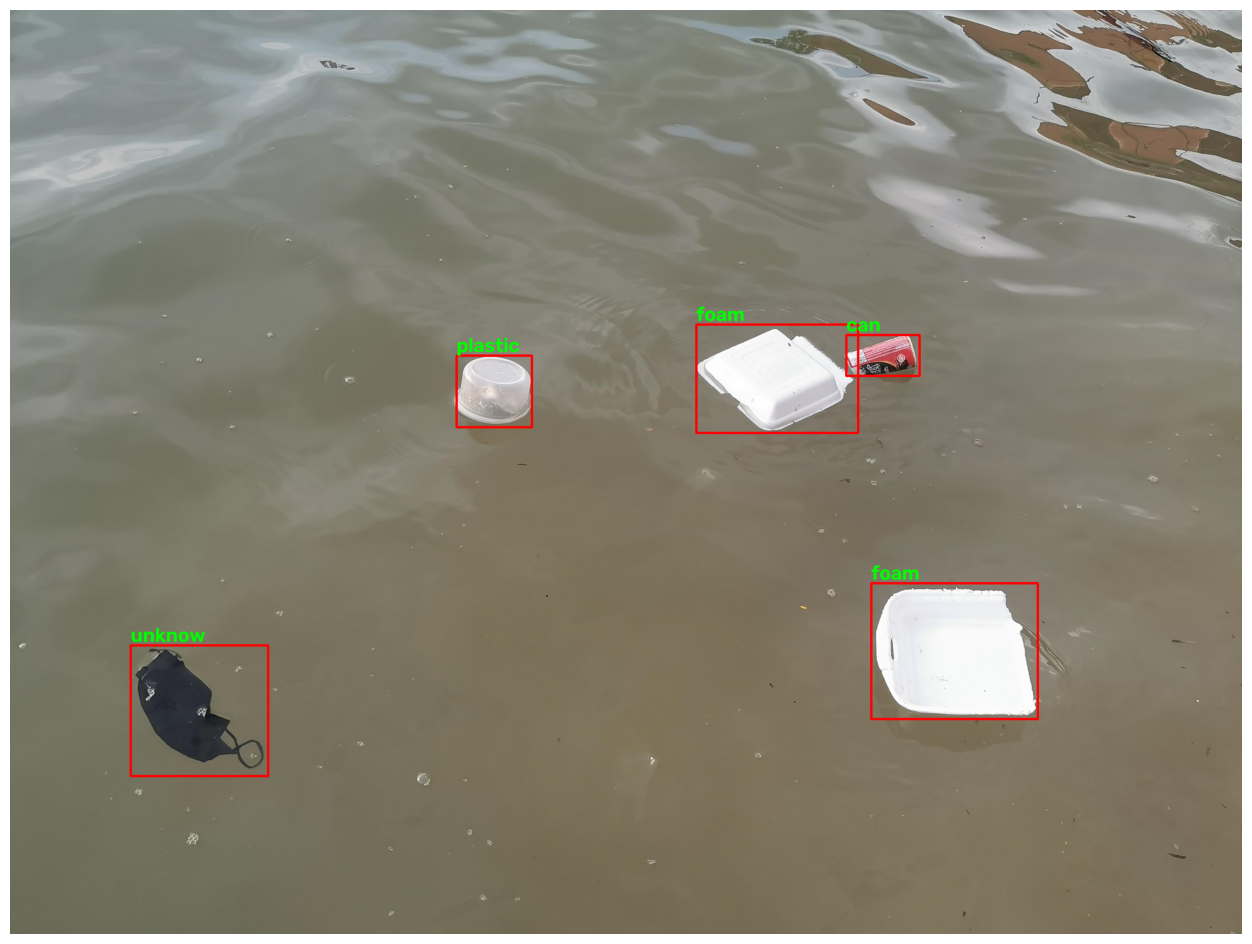

In [ ]:
import json
import random
import cv2
import matplotlib.pyplot as plt
import os

# Paths
BASE_DIR = "/content/drive/My Drive/Computer Vision Project"
SOURCE_DIR = os.path.join(BASE_DIR, "Dataset", "marine debris object detection")
train_dir = os.path.join(SOURCE_DIR, "train")
annotation_file = os.path.join(train_dir, "_annotations.coco.json")

# Load COCO annotations
with open(annotation_file, "r") as f:
    coco = json.load(f)

categories = {cat["id"]: cat["name"] for cat in coco["categories"]}

# Group annotations by image
annotations_per_image = {}
for ann in coco["annotations"]:
    annotations_per_image.setdefault(ann["image_id"], []).append(ann)

# Pick one random image
img_info = random.choice(coco["images"])

img_path = os.path.join(train_dir, img_info["file_name"])

image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

anns = annotations_per_image.get(img_info["id"], [])

for ann in anns:

    x, y, w, h = map(int, ann["bbox"])

    cv2.rectangle(image, (x, y), (x+w, y+h), (255, 0, 0), 5)

    cv2.putText(
        image,
        categories[ann["category_id"]],
        (x, max(40, y-10)),
        cv2.FONT_HERSHEY_SIMPLEX,
        2,
        (0,255,0),
        5
    )

plt.figure(figsize=(18,12))
plt.imshow(image)
plt.axis("off")
plt.show()

**Bar Graph**

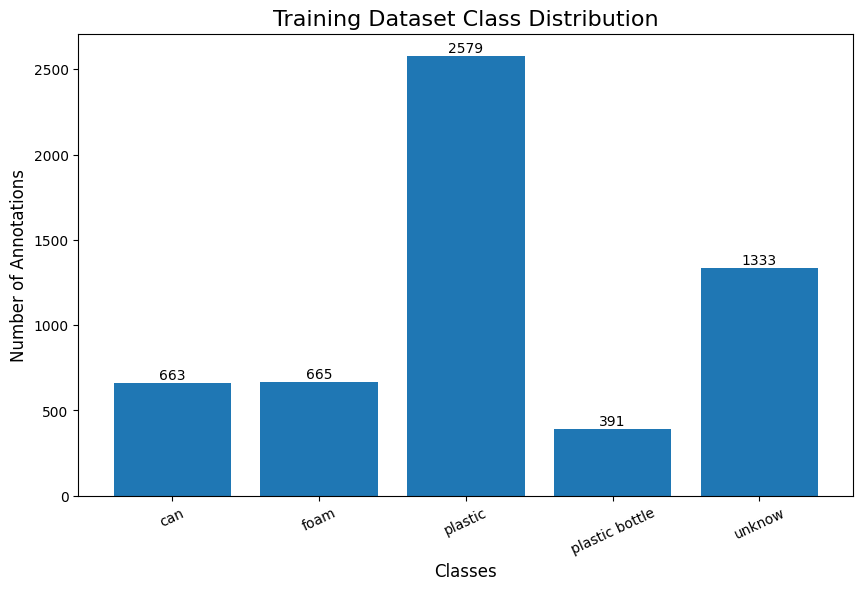

In [ ]:
import json
from collections import Counter
import matplotlib.pyplot as plt
import os

BASE_DIR = "/content/drive/My Drive/Computer Vision Project"
SOURCE_DIR = os.path.join(BASE_DIR, "Dataset", "marine debris object detection")
annotation_file = os.path.join(SOURCE_DIR, "train", "_annotations.coco.json")

with open(annotation_file, "r") as f:
    coco = json.load(f)

# Category names
categories = {cat["id"]: cat["name"] for cat in coco["categories"]}

# Count annotations
counter = Counter()

for ann in coco["annotations"]:
    counter[ann["category_id"]] += 1

labels = []
values = []

for cid in sorted(categories.keys()):
    if counter[cid] > 0:
        labels.append(categories[cid])
        values.append(counter[cid])

plt.figure(figsize=(10,6))
plt.bar(labels, values)

plt.title("Training Dataset Class Distribution", fontsize=16)
plt.xlabel("Classes", fontsize=12)
plt.ylabel("Number of Annotations", fontsize=12)

plt.xticks(rotation=25)

for i, v in enumerate(values):
    plt.text(i, v+20, str(v), ha="center")

plt.show()

**Pie Chart**

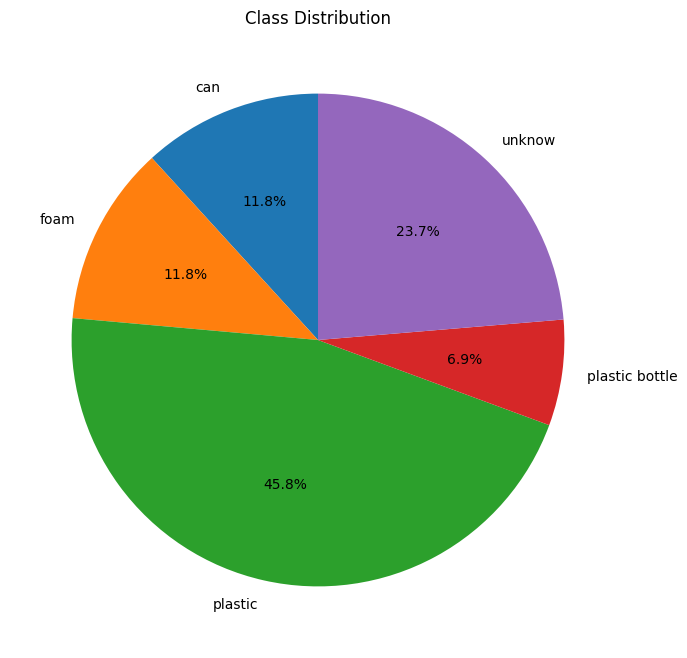

In [ ]:
plt.figure(figsize=(8,8))

plt.pie(
    values,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Class Distribution")

plt.show()

# Phase 4 - Data Preparation

In [ ]:
# Install Ultralytics (YOLO)
!pip install -q ultralytics

# Check installation
import ultralytics
print("Ultralytics Version:", ultralytics.__version__)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.1/46.1 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 75.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 6.9 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Ultralytics Version: 8.4.140


**Verify GPU**

In [ ]:
import torch

print("CUDA Available :", torch.cuda.is_available())
print("GPU Name :", torch.cuda.get_device_name(0))

CUDA Available : True
GPU Name : Tesla T4


**Create Output Folders**

In [ ]:
import os

BASE_DIR = "/content/drive/My Drive/Computer Vision Project"

OUTPUT_DIR = os.path.join(BASE_DIR, "Marine_Debris_YOLO")

folders = [
    "train/images",
    "train/labels",
    "valid/images",
    "valid/labels"
]

for folder in folders:
    os.makedirs(os.path.join(OUTPUT_DIR, folder), exist_ok=True)

print("Folders created successfully!")

print("\nFolder Structure:")

for root, dirs, files in os.walk(OUTPUT_DIR):
    print(root)

Folders created successfully!

Folder Structure:
/content/drive/My Drive/Computer Vision Project/Marine_Debris_YOLO
/content/drive/My Drive/Computer Vision Project/Marine_Debris_YOLO/train
/content/drive/My Drive/Computer Vision Project/Marine_Debris_YOLO/train/images
/content/drive/My Drive/Computer Vision Project/Marine_Debris_YOLO/train/labels
/content/drive/My Drive/Computer Vision Project/Marine_Debris_YOLO/valid
/content/drive/My Drive/Computer Vision Project/Marine_Debris_YOLO/valid/images
/content/drive/My Drive/Computer Vision Project/Marine_Debris_YOLO/valid/labels


**Converting COCO to YOLO**

In [ ]:
import os
import json
import shutil

BASE_DIR = "/content/drive/My Drive/Computer Vision Project"

SOURCE_DIR = os.path.join(BASE_DIR,
                          "Dataset",
                          "marine debris object detection")

OUTPUT_DIR = os.path.join(BASE_DIR,
                          "Marine_Debris_YOLO")


def convert_dataset(split):

    image_folder = os.path.join(SOURCE_DIR, split)

    annotation_file = os.path.join(
        image_folder,
        "_annotations.coco.json"
    )

    with open(annotation_file, "r") as f:
        coco = json.load(f)

    images = {img["id"]: img for img in coco["images"]}

    annotations = {}

    for ann in coco["annotations"]:
        annotations.setdefault(
            ann["image_id"], []
        ).append(ann)

    converted = 0

    for image_id, image_info in images.items():

        image_name = image_info["file_name"]

        width = image_info["width"]

        height = image_info["height"]

        src_image = os.path.join(
            image_folder,
            image_name
        )

        dst_image = os.path.join(
            OUTPUT_DIR,
            split,
            "images",
            image_name
        )

        shutil.copy(src_image, dst_image)

        label_path = os.path.join(
            OUTPUT_DIR,
            split,
            "labels",
            image_name.replace(".jpg", ".txt")
        )

        with open(label_path, "w") as f:

            for ann in annotations.get(image_id, []):

                x, y, w, h = ann["bbox"]

                x_center = (x + w / 2) / width

                y_center = (y + h / 2) / height

                w /= width

                h /= height

                class_id = ann["category_id"] - 1

                f.write(
                    f"{class_id} "
                    f"{x_center:.6f} "
                    f"{y_center:.6f} "
                    f"{w:.6f} "
                    f"{h:.6f}\n"
                )

        converted += 1

    print(f"{split.upper()} converted successfully!")
    print(f"Images converted: {converted}")


convert_dataset("train")
convert_dataset("valid")

TRAIN converted successfully!
Images converted: 445
VALID converted successfully!
Images converted: 130


**Create data.yaml**

In [ ]:
yaml_text = """
path: /content/drive/MyDrive/Computer Vision Project/Marine_Debris_YOLO

train: train/images
val: valid/images

names:
  0: can
  1: foam
  2: plastic
  3: plastic bottle
  4: unknow
"""

yaml_path = "/content/drive/My Drive/Computer Vision Project/Marine_Debris_YOLO/data.yaml"

with open(yaml_path, "w") as f:
    f.write(yaml_text)

print("data.yaml created successfully!")

data.yaml created successfully!


**Verify the Conversion**

In [ ]:
import os

base = "/content/drive/My Drive/Computer Vision Project/Marine_Debris_YOLO"

for split in ["train", "valid"]:

    img_path = os.path.join(base, split, "images")
    lbl_path = os.path.join(base, split, "labels")

    images = len([f for f in os.listdir(img_path)
                  if f.endswith((".jpg", ".png", ".jpeg"))])

    labels = len([f for f in os.listdir(lbl_path)
                  if f.endswith(".txt")])

    print(f"{split.upper()}")
    print(f"Images : {images}")
    print(f"Labels : {labels}")
    print("-"*30)

TRAIN
Images : 445
Labels : 445
------------------------------
VALID
Images : 130
Labels : 130
------------------------------


# Phase 5 - Base Data Training (YOLO11n, 640 px)

**Training Code**

we are using YOLO version 11 model

In [ ]:
from ultralytics import YOLO

# Load pretrained YOLO model
model = YOLO("yolo11n.pt")

# Train
results = model.train(
    data="/content/drive/My Drive/Computer Vision Project/Marine_Debris_YOLO/data.yaml",
    epochs=50, #early stopping will prevent overfitting
    imgsz=640, #standard for YOLO
    batch=16,
    device=0,
    workers=2,
    project="/content/drive/My Drive/Computer Vision Project",
    name="Base_Marine_Debris_Detection",
    pretrained=True, #My dataset is pre trained, used for fine tuning
    patience=10, # stops training when datset performance stops improving
    verbose=True
)

Ultralytics 8.4.118 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/My Drive/Computer Vision Project/Marine_Debris_YOLO/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_

# Phase 6 — Base Evaluate the model

**evaluate the model on the validation dataset.**

In [ ]:
from ultralytics import YOLO

best_model = YOLO(
    "/content/drive/My Drive/Computer Vision Project/Base_Marine_Debris_Detection/weights/best.pt"
)

metrics = best_model.val(
    data="/content/drive/My Drive/Computer Vision Project/Marine_Debris_YOLO/data.yaml",
    imgsz=640,
    batch=16,
    device=0,
    plots=True
)

Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,583,127 parameters, 0 gradients, 6.4 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 10.9±23.5 ms, read: 181.9±182.1 MB/s, size: 796.3 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /content/drive/MyDrive/Computer Vision Project/Marine_Debris_YOLO/valid/labels.cache... 130 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 130/130 27.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 1.2s/it 10.9s
                   all        130       1285      0.529      0.465      0.553      0.321
                   can         21         29      0.387      0.966       0.94      0.616
                  foam         78        109      0.654      0.434      0.593      0.348
               pl

Here the valuation matrixes are low at performance. Let's inspect YOLO's validation predictions

In [ ]:
from ultralytics import YOLO
from IPython.display import Image, display
import os

best_model = YOLO(
    "/content/drive/My Drive/Computer Vision Project/Base_Marine_Debris_Detection/weights/best.pt"
)

results = best_model.predict(
    source="/content/drive/My Drive/Computer Vision Project/Marine_Debris_YOLO/valid/images",
    imgsz=640,
    conf=0.25,
    save=True,
    project="/content/drive/My Drive/Computer Vision Project/runs",
    name="validation_predictions_Base",
    device=0
)

print("Prediction completed.")
print("Saved to:")
print("/content/drive/My Drive/Computer Vision Project/runs/validation_predictions")


image 1/130 /content/drive/My Drive/Computer Vision Project/Marine_Debris_YOLO/valid/images/marine-debris-158-_jpg.rf.dcca1fdb690c507683c87dd7d40206c2.jpg: 480x640 1 can, 1 foam, 1 plastic, 7.6ms
image 2/130 /content/drive/My Drive/Computer Vision Project/Marine_Debris_YOLO/valid/images/marine-debris-159-_jpg.rf.ae1b0076ac420e85024392fe1a113609.jpg: 480x640 1 can, 1 plastic, 2 plastic bottles, 21.4ms
image 3/130 /content/drive/My Drive/Computer Vision Project/Marine_Debris_YOLO/valid/images/marine-debris-160-_jpg.rf.460f4da00f1bd67fadbd086b14215257.jpg: 480x640 1 can, 3 plastics, 2 plastic bottles, 8.2ms
image 4/130 /content/drive/My Drive/Computer Vision Project/Marine_Debris_YOLO/valid/images/marine-debris-161-_jpg.rf.42b081d20792a4ec3fa2ad9c96e7e582.jpg: 480x640 1 can, 3 plastics, 2 plastic bottles, 8.4ms
image 5/130 /content/drive/My Drive/Computer Vision Project/Marine_Debris_YOLO/valid/images/marine-debris-162-_jpg.rf.62132a7167bca4720f88004d802b1b1f.jpg: 480x640 1 can, 2 plasti

display a few predictions

In [ ]:
import os
import random
from IPython.display import Image, display

prediction_dir = "/content/drive/My Drive/Computer Vision Project/runs/validation_predictions_Base"

images = [
    f for f in os.listdir(prediction_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

samples = random.sample(images, min(10, len(images)))

for img in samples:
    print("\n", img)
    display(Image(
        filename=os.path.join(prediction_dir, img),
        width=800
    ))

# Experiment 1 (YOLO11n, 960 px)

increasing image size to 960

In [ ]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")
results = model.train(
    data="/content/drive/My Drive/Computer Vision Project/Marine_Debris_YOLO/data.yaml",

    epochs=50,

    imgsz=960,

    batch=16,

    device=0,

    project="/content/drive/My Drive/Computer Vision Project",

    name="Exp_1_YOLO11n_960_Detection",

    patience=10,

    workers=2,

    pretrained=True,

    verbose=True
)

Ultralytics 8.4.118 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/My Drive/Computer Vision Project/Marine_Debris_YOLO/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_

Experiment 1 Evaluation

In [ ]:
from ultralytics import YOLO

best_model = YOLO(
    "/content/drive/My Drive/Computer Vision Project/Exp_1_YOLO11n_960_Detection/weights/best.pt"
)

metrics = best_model.val(
    data="/content/drive/My Drive/Computer Vision Project/Marine_Debris_YOLO/data.yaml",
    imgsz=960,
    device=0,
    batch=16,
    plots=True
)

Ultralytics 8.4.118 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,583,127 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.5±0.2 ms, read: 77.2±123.5 MB/s, size: 981.4 KB)
val: Scanning /content/drive/MyDrive/Computer Vision Project/Marine_Debris_YOLO/valid/labels.cache... 130 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 130/130 22.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 1.6s/it 14.7s
                   all        130       1285      0.567      0.548      0.584      0.338
                   can         21         29      0.552          1       0.92      0.574
                  foam         78        109      0.673      0.486      0.587      0.375
               plastic         99        378      0.521      0.431      0.451      0.213
        plastic bottle        110        446      0.746      0.534      0.679      0.38

YOLO's validation predictions

In [ ]:
from ultralytics import YOLO
from IPython.display import Image, display
import os

best_model = YOLO(
    "/content/drive/My Drive/Computer Vision Project/Exp_1_YOLO11n_960_Detection/weights/best.pt"
)

results = best_model.predict(
    source="/content/drive/My Drive/Computer Vision Project/Marine_Debris_YOLO/valid/images",
    imgsz=960,
    conf=0.25,
    save=True,
    project="/content/drive/My Drive/Computer Vision Project/runs",
    name="validation_predictions_exp_1",
    device=0
)

print("Prediction completed.")
print("Saved to:")
print("/content/drive/My Drive/Computer Vision Project/runs/validation_predictions")


image 1/130 /content/drive/My Drive/Computer Vision Project/Marine_Debris_YOLO/valid/images/marine-debris-158-_jpg.rf.dcca1fdb690c507683c87dd7d40206c2.jpg: 736x960 1 can, 1 foam, 1 plastic, 11.5ms
image 2/130 /content/drive/My Drive/Computer Vision Project/Marine_Debris_YOLO/valid/images/marine-debris-159-_jpg.rf.ae1b0076ac420e85024392fe1a113609.jpg: 736x960 1 can, 1 plastic, 2 plastic bottles, 21.8ms
image 3/130 /content/drive/My Drive/Computer Vision Project/Marine_Debris_YOLO/valid/images/marine-debris-160-_jpg.rf.460f4da00f1bd67fadbd086b14215257.jpg: 736x960 1 can, 2 plastics, 2 plastic bottles, 11.6ms
image 4/130 /content/drive/My Drive/Computer Vision Project/Marine_Debris_YOLO/valid/images/marine-debris-161-_jpg.rf.42b081d20792a4ec3fa2ad9c96e7e582.jpg: 736x960 1 can, 1 plastic, 2 plastic bottles, 11.5ms
image 5/130 /content/drive/My Drive/Computer Vision Project/Marine_Debris_YOLO/valid/images/marine-debris-162-_jpg.rf.62132a7167bca4720f88004d802b1b1f.jpg: 736x960 1 can, 1 plas

Exp 1 display a few predictions

In [ ]:
import os
import random
from IPython.display import Image, display

prediction_dir = "/content/drive/My Drive/Computer Vision Project/runs/validation_predictions_exp_1"

images = [
    f for f in os.listdir(prediction_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

samples = random.sample(images, min(10, len(images)))

for img in samples:
    print("\n", img)
    display(Image(
        filename=os.path.join(prediction_dir, img),
        width=800
    ))

# Experiment 2 (YOLO11s, 960 px)


**Using YOLOs and 960 pixels**

In [ ]:
model = YOLO("yolo11s.pt")

results = model.train(
    data="/content/drive/My Drive/Computer Vision Project/Marine_Debris_YOLO/data.yaml",

    epochs=50,
    imgsz=960,
    batch=16,
    device=0,

    project="/content/drive/My Drive/Computer Vision Project",
    name="Exp_2_YOLO11s_960_Detection",

    patience=10,
    workers=2,
    pretrained=True,
    verbose=True
)

Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/My Drive/Computer Vision Project/Marine_Debris_YOLO/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_

Experiment 2 evaluation

In [ ]:
from ultralytics import YOLO

best_model = YOLO(
    "/content/drive/My Drive/Computer Vision Project/Exp_2_YOLO11s_960_Detection/weights/best.pt"
)

metrics = best_model.val(
    data="/content/drive/My Drive/Computer Vision Project/Marine_Debris_YOLO/data.yaml",
    imgsz=960,
    batch=16,
    device=0,
    plots=True
)

Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,414,735 parameters, 0 gradients, 21.4 GFLOPs
val: Fast image access ✅ (ping: 0.6±0.4 ms, read: 350.4±94.7 MB/s, size: 911.5 KB)
val: Scanning /content/drive/MyDrive/Computer Vision Project/Marine_Debris_YOLO/valid/labels.cache... 130 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 130/130 22.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 1.5s/it 13.3s
                   all        130       1285      0.529      0.538      0.571      0.332
                   can         21         29      0.453      0.973      0.868      0.556
                  foam         78        109      0.608      0.568      0.635      0.396
               plastic         99        378      0.543      0.437      0.467      0.229
        plastic bottle        110        446      0.703      0.576      0.662      0.3

# Experiment 3 (YOLO11s, 1280 px)

**Using YOLOs and 1280 pixels**

In [ ]:
from ultralytics import YOLO

model = YOLO("yolo11s.pt")

results = model.train(
    data="/content/drive/My Drive/Computer Vision Project/Marine_Debris_YOLO/data.yaml",

    epochs=50,
    imgsz=1280,
    batch=16,
    device=0,

    project="/content/drive/My Drive/Computer Vision Project",
    name="Exp_3_YOLO11s_1280_Detection",

    patience=10,
    workers=2,
    pretrained=True,
    verbose=True
)

Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/My Drive/Computer Vision Project/Marine_Debris_YOLO/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi

Experiment 3 evaluation

In [ ]:
from ultralytics import YOLO

best_model = YOLO(
    "/content/drive/My Drive/Computer Vision Project/Exp_3_YOLO11s_1280_Detection/weights/best.pt"
)

metrics = best_model.val(
    data="/content/drive/My Drive/Computer Vision Project/Marine_Debris_YOLO/data.yaml",
    imgsz=1280,
    batch=16,
    device=0,
    plots=True
)

Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,414,735 parameters, 0 gradients, 21.4 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 320.3±78.7 MB/s, size: 669.0 KB)
val: Scanning /content/drive/MyDrive/Computer Vision Project/Marine_Debris_YOLO/valid/labels.cache... 130 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 130/130 30.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 1.7s/it 15.3s
                   all        130       1285      0.677      0.523      0.599      0.369
                   can         21         29      0.631      0.966      0.831      0.569
                  foam         78        109      0.693      0.394      0.576      0.394
               plastic         99        378       0.64       0.46      0.519      0.264
        plastic bottle        110        446      0.815      0.581      0.742      0.4

# Experiment 4 (Controlled YOLO11s, 1280 px)

Controlled YOLO11s, with 1280 pixels, 15 patience

In [ ]:
from ultralytics import YOLO

model = YOLO("yolo11s.pt")

results = model.train(
    data="/content/drive/My Drive/Computer Vision Project/Marine_Debris_YOLO/data.yaml",

    epochs=50,
    imgsz=1280,
    batch=16,
    device=0,

    project="/content/drive/My Drive/Computer Vision Project",
    name="Exp_4_Cotrolled_YOLO11s_1280_Detection",

    patience=15,
    workers=2,
    pretrained=True,
    verbose=True
)

Ultralytics 8.4.121 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/My Drive/Computer Vision Project/Marine_Debris_YOLO/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi

Evaluation of experiment 4

In [ ]:
from ultralytics import YOLO

best_model = YOLO(
    "/content/drive/My Drive/Computer Vision Project/Exp_4_Cotrolled_YOLO11s_1280_Detection/weights/best.pt"
)

metrics = best_model.val(
    data="/content/drive/My Drive/Computer Vision Project/Marine_Debris_YOLO/data.yaml",
    imgsz=1280,
    batch=16,
    device=0,
    plots=True
)

Ultralytics 8.4.121 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,414,735 parameters, 0 gradients, 21.4 GFLOPs
val: Fast image access ✅ (ping: 8.6±18.4 ms, read: 150.8±121.0 MB/s, size: 914.7 KB)
val: Scanning /content/drive/MyDrive/Computer Vision Project/Marine_Debris_YOLO/valid/labels.cache... 130 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 130/130 7.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 1.7s/it 15.2s
                   all        130       1285      0.677      0.523      0.599      0.369
                   can         21         29      0.631      0.966      0.831      0.569
                  foam         78        109      0.693      0.394      0.576      0.394
               plastic         99        378       0.64       0.46      0.519      0.264
        plastic bottle        110        446      0.815      0.581      0.742      0.

# Data inspection before experiment 5

In [ ]:
import yaml

yaml_path = "/content/drive/My Drive/Computer Vision Project/Marine_Debris_YOLO/data.yaml"

with open(yaml_path, "r") as f:
    data = yaml.safe_load(f)

print(data)

{'path': '/content/drive/MyDrive/Computer Vision Project/Marine_Debris_YOLO', 'train': 'train/images', 'val': 'valid/images', 'names': {0: 'can', 1: 'foam', 2: 'plastic', 3: 'plastic bottle', 4: 'unknow'}}


In [ ]:
from collections import Counter
import os

labels_dir = "/content/drive/My Drive/Computer Vision Project/Marine_Debris_YOLO/train/labels"

class_counts = Counter()

for file in os.listdir(labels_dir):
    if file.endswith(".txt"):
        with open(os.path.join(labels_dir, file), "r") as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    class_counts[int(parts[0])] += 1

print("Training instances:")
for class_id, count in sorted(class_counts.items()):
    print(class_id, data["names"][class_id], count)

Training instances:
0 can 663
1 foam 665
2 plastic 2579
3 plastic bottle 391
4 unknow 1333


It will select random examples of each class and draw their bounding boxes.

In [ ]:
import os
import random
import cv2
import matplotlib.pyplot as plt

IMAGE_DIR = "/content/drive/My Drive/Computer Vision Project/Marine_Debris_YOLO/train/images"
LABEL_DIR = "/content/drive/My Drive/Computer Vision Project/Marine_Debris_YOLO/train/labels"

CLASS_NAMES = {
    0: "can",
    1: "foam",
    2: "plastic",
    3: "plastic bottle",
    4: "unknow"
}

# Number of samples per class
SAMPLES_PER_CLASS = 5

class_files = {i: [] for i in CLASS_NAMES}

# Find images containing each class
for label_file in os.listdir(LABEL_DIR):

    if not label_file.endswith(".txt"):
        continue

    label_path = os.path.join(LABEL_DIR, label_file)

    with open(label_path, "r") as f:
        lines = f.readlines()

    classes_in_image = set()

    for line in lines:
        parts = line.strip().split()

        if len(parts) >= 5:
            class_id = int(parts[0])
            classes_in_image.add(class_id)

    image_name = os.path.splitext(label_file)[0]

    for class_id in classes_in_image:
        if class_id in class_files:
            class_files[class_id].append(image_name)


# Display samples
for class_id, class_name in CLASS_NAMES.items():

    samples = random.sample(
        class_files[class_id],
        min(SAMPLES_PER_CLASS, len(class_files[class_id]))
    )

    print("\n" + "=" * 60)
    print(f"CLASS: {class_name}")
    print("=" * 60)

    for image_name in samples:

        image_path = os.path.join(IMAGE_DIR, image_name + ".jpg")

        if not os.path.exists(image_path):
            continue

        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        h, w, _ = image.shape

        label_path = os.path.join(LABEL_DIR, image_name + ".txt")

        with open(label_path, "r") as f:
            lines = f.readlines()

        for line in lines:

            parts = line.strip().split()

            if len(parts) != 5:
                continue

            cls, xc, yc, bw, bh = map(float, parts)

            cls = int(cls)

            # Convert YOLO coordinates to pixels
            x1 = int((xc - bw / 2) * w)
            y1 = int((yc - bh / 2) * h)
            x2 = int((xc + bw / 2) * w)
            y2 = int((yc + bh / 2) * h)

            # Draw rectangle
            cv2.rectangle(
                image,
                (x1, y1),
                (x2, y2),
                (255, 0, 0),
                3
            )

            cv2.putText(
                image,
                CLASS_NAMES[cls],
                (x1, max(y1 - 10, 20)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.8,
                (255, 0, 0),
                2
            )

        plt.figure(figsize=(10, 7))
        plt.imshow(image)
        plt.title(f"{class_name} — {image_name}")
        plt.axis("off")
        plt.show()

# Randomely experiment (1280, yolo11n)

In [ ]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

results = model.train(
    data="/content/drive/My Drive/Computer Vision Project/Marine_Debris_YOLO/data.yaml",

    epochs=50,
    imgsz=1280,
    batch=16,
    device=0,

    project="/content/drive/My Drive/Computer Vision Project",
    name="emnei_YOLO11n_1280_Detection",

    patience=10,
    workers=2,
    pretrained=True,
    verbose=True
)

Ultralytics 8.4.121 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/My Drive/Computer Vision Project/Marine_Debris_YOLO/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi

In [ ]:
from ultralytics import YOLO

best_model = YOLO(
    "/content/drive/My Drive/Computer Vision Project/emnei_YOLO11n_1280_Detection/weights/best.pt"
)

metrics = best_model.val(
    data="/content/drive/My Drive/Computer Vision Project/Marine_Debris_YOLO/data.yaml",
    imgsz=1280,
    batch=16,
    device=0,
    plots=True
)

Ultralytics 8.4.121 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,583,127 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 2.5±4.6 ms, read: 134.8±101.2 MB/s, size: 709.9 KB)
val: Scanning /content/drive/MyDrive/Computer Vision Project/Marine_Debris_YOLO/valid/labels.cache... 130 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 130/130 17.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 1.3s/it 12.0s
                   all        130       1285      0.541      0.547      0.566      0.332
                   can         21         29      0.413          1       0.88      0.552
                  foam         78        109      0.636      0.464      0.545      0.365
               plastic         99        378      0.482       0.46        0.4      0.187
        plastic bottle        110        446      0.793      0.545      0.726      0.4

In [ ]:
import os

base = "/content/drive/MyDrive/Computer Vision Project"

for root, dirs, files in os.walk(base):
    for file in files:
        if file == "best.pt":
            path = os.path.join(root, file)
            print(path)

/content/drive/MyDrive/Computer Vision Project/Exp_1_YOLO11n_960_Detection/weights/best.pt
/content/drive/MyDrive/Computer Vision Project/Base_Marine_Debris_Detection/weights/best.pt
/content/drive/MyDrive/Computer Vision Project/Exp_2_YOLO11s_960_Detection/weights/best.pt
/content/drive/MyDrive/Computer Vision Project/Exp_3_YOLO11s_1280_Detection/weights/best.pt
/content/drive/MyDrive/Computer Vision Project/Exp_4_Cotrolled_YOLO11s_1280_Detection/weights/best.pt


# Experiment 5 (YOLO11s + 1280 + stronger augmentation)

In [ ]:
from ultralytics import YOLO

model = YOLO("yolo11s.pt")

results = model.train(
    data="/content/drive/MyDrive/Computer Vision Project/Marine_Debris_YOLO/data.yaml",

    epochs=80,
    imgsz=1280,
    batch=8,

    device=0,

    patience=15,

    pretrained=True,

    degrees=10,
    translate=0.1,
    scale=0.5,
    shear=2.0,

    fliplr=0.5,

    mosaic=1.0,
    mixup=0.1,

    project="/content/drive/MyDrive/Computer Vision Project",
    name="Experiment_5_YOLO11s_1280_Augmented",

    workers=2,
    verbose=True
)

Ultralytics 8.4.121 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Computer Vision Project/Marine_Debris_YOLO/data.yaml, degrees=10, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_sc

In [ ]:
from ultralytics import YOLO

best_model = YOLO(
    "/content/drive/My Drive/Computer Vision Project/Experiment_5_YOLO11s_1280_Augmented/weights/best.pt"
)

metrics = best_model.val(
    data="/content/drive/My Drive/Computer Vision Project/Marine_Debris_YOLO/data.yaml",
    imgsz=1280,
    batch=8,
    device=0,
    plots=True
)

Ultralytics 8.4.121 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,414,735 parameters, 0 gradients, 21.4 GFLOPs
val: Fast image access ✅ (ping: 1.2±1.1 ms, read: 193.1±154.8 MB/s, size: 846.6 KB)
val: Scanning /content/drive/MyDrive/Computer Vision Project/Marine_Debris_YOLO/valid/labels.cache... 130 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 130/130 21.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 17/17 1.5it/s 11.4s
                   all        130       1285      0.618       0.56      0.597      0.356
                   can         21         29       0.69      0.997      0.957      0.602
                  foam         78        109      0.425      0.697      0.574      0.379
               plastic         99        378      0.599      0.384      0.493       0.26
        plastic bottle        110        446      0.748      0.612      0.696      

# Experiment 6 (YOLO11s, 1280 but 80 epochs)

In [ ]:
from ultralytics import YOLO

model = YOLO("yolo11s.pt")

results = model.train(
    data="/content/drive/MyDrive/Computer Vision Project/Marine_Debris_YOLO/data.yaml",

    epochs=80,
    imgsz=1280,
    batch=8,

    device=0,

    patience=15,

    pretrained=True,

    # Class imbalance experiment
    cls_pw=0.5,

    project="/content/drive/MyDrive/Computer Vision Project",
    name="Experiment_6_YOLO11s_1280_ClassWeighted",

    workers=2,
    verbose=True
)

Ultralytics 8.4.121 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.5, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Computer Vision Project/Marine_Debris_YOLO/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_s

In [ ]:
from ultralytics import YOLO

best_model = YOLO(
    "/content/drive/My Drive/Computer Vision Project/Experiment_6_YOLO11s_1280_ClassWeighted/weights/best.pt"
)

metrics = best_model.val(
    data="/content/drive/My Drive/Computer Vision Project/Marine_Debris_YOLO/data.yaml",
    imgsz=1280,
    batch=8,
    device=0,
    plots=True
)

Ultralytics 8.4.121 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,414,735 parameters, 0 gradients, 21.4 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 301.8±169.2 MB/s, size: 669.5 KB)
val: Scanning /content/drive/MyDrive/Computer Vision Project/Marine_Debris_YOLO/valid/labels.cache... 130 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 130/130 13.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 17/17 1.5it/s 11.4s
                   all        130       1285      0.589      0.587      0.593      0.363
                   can         21         29       0.76      0.897      0.913      0.598
                  foam         78        109      0.682       0.45      0.572      0.405
               plastic         99        378      0.419      0.627      0.494      0.249
        plastic bottle        110        446       0.69      0.722      0.758      

# Experiment 3 is the best model here. So we will use the experiment 3 model

In [ ]:
import os
import shutil

project_path = "/content/drive/MyDrive/Computer Vision Project"

best_model = (
    project_path +
    "/Exp_3_YOLO11s_1280_Detection/weights/best.pt"
)

final_folder = project_path + "/Final_Model"
os.makedirs(final_folder, exist_ok=True)
final_model = final_folder + "/Marine_Debris_YOLO11s_1280_best.pt"
shutil.copy2(best_model, final_model)

print("Final model saved:")
print(final_model)

Final model saved:
/content/drive/MyDrive/Computer Vision Project/Final_Model/Marine_Debris_YOLO11s_1280_best.pt


validating one more time

In [ ]:
from ultralytics import YOLO

model = YOLO(
    "/content/drive/MyDrive/Computer Vision Project/Final_Model/Marine_Debris_YOLO11s_1280_best.pt"
)

metrics = model.val(
    data="/content/drive/MyDrive/Computer Vision Project/Marine_Debris_YOLO/data.yaml",
    imgsz=1280,
    device=0,
    plots=True
)

print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Ultralytics 8.4.122 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,414,735 parameters, 0 gradients, 21.4 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 451.1±87.7 MB/s, size: 957.5 KB)
val: Scanning /content/drive/MyDrive/Computer Vision Project/Marine_Debris_YOLO/valid/labels.cache... 130 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 130/130 21.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 1.5s/it 13.9s
                   all        130       1285      0.677      0.523      0.599      0.369
                   can         21         29      0.631      0.966      0.831      0.569
                  foam         78        109      0.693      0.394      0.576      0.394
               plastic         99        378       0.64       0.46      0.519      0.264
        plastic bottle        110        446      0.815      0.581      0.742      0.4

In [ ]:
from ultralytics import YOLO
from IPython.display import Image, display
import os

best_model = YOLO(
    "/content/drive/MyDrive/Computer Vision Project/Final_Model/Marine_Debris_YOLO11s_1280_best.pt"
)

results = best_model.predict(
    source="/content/drive/My Drive/Computer Vision Project/Marine_Debris_YOLO/valid/images",
    imgsz=1280,
    conf=0.25,
    save=True,
    project="/content/drive/My Drive/Computer Vision Project/runs",
    name="validation_predictions_Best_Model",
    device=0
)

print("Prediction completed.")
print("Saved to:")
print("/content/drive/My Drive/Computer Vision Project/runs/validation_predictions")


image 1/130 /content/drive/My Drive/Computer Vision Project/Marine_Debris_YOLO/valid/images/marine-debris-158-_jpg.rf.dcca1fdb690c507683c87dd7d40206c2.jpg: 960x1280 1 can, 2 foams, 1 plastic, 36.5ms
image 2/130 /content/drive/My Drive/Computer Vision Project/Marine_Debris_YOLO/valid/images/marine-debris-159-_jpg.rf.ae1b0076ac420e85024392fe1a113609.jpg: 960x1280 1 can, 1 plastic, 2 plastic bottles, 36.6ms
image 3/130 /content/drive/My Drive/Computer Vision Project/Marine_Debris_YOLO/valid/images/marine-debris-160-_jpg.rf.460f4da00f1bd67fadbd086b14215257.jpg: 960x1280 1 can, 1 plastic, 2 plastic bottles, 36.5ms
image 4/130 /content/drive/My Drive/Computer Vision Project/Marine_Debris_YOLO/valid/images/marine-debris-161-_jpg.rf.42b081d20792a4ec3fa2ad9c96e7e582.jpg: 960x1280 1 can, 1 plastic, 2 plastic bottles, 36.6ms
image 5/130 /content/drive/My Drive/Computer Vision Project/Marine_Debris_YOLO/valid/images/marine-debris-162-_jpg.rf.62132a7167bca4720f88004d802b1b1f.jpg: 960x1280 1 can, 1

# Testing with unseen Images

Running detection on new images

In [ ]:
from ultralytics import YOLO
import os

model_path = "/content/drive/MyDrive/Computer Vision Project/Final_Model/Marine_Debris_YOLO11s_1280_best.pt"

model = YOLO(model_path)

test_images = "/content/drive/MyDrive/Computer Vision Project/Test_Images"

results = model.predict(
    source=test_images,
    imgsz=1280,
    conf=0.25,
    save=True,
    save_txt=True,
    save_conf=True,
    project="/content/drive/MyDrive/Computer Vision Project",
    name="Final_Image_Test_Results"
)

print("Detection completed.")


image 1/12 /content/drive/MyDrive/Computer Vision Project/Test_Images/Waste (1).jpg: 960x1280 3 plastics, 1 unknow, 36.5ms
image 2/12 /content/drive/MyDrive/Computer Vision Project/Test_Images/Waste (10).jpg: 960x1280 6 plastics, 6 plastic bottles, 13 unknows, 36.6ms
image 3/12 /content/drive/MyDrive/Computer Vision Project/Test_Images/Waste (11).jpg: 864x1280 2 cans, 2 plastics, 3 plastic bottles, 4 unknows, 33.4ms
image 4/12 /content/drive/MyDrive/Computer Vision Project/Test_Images/Waste (12).jpg: 864x1280 1 plastic, 29.1ms
image 5/12 /content/drive/MyDrive/Computer Vision Project/Test_Images/Waste (13).jpg: 864x1280 1 plastic bottle, 1 unknow, 29.1ms
image 6/12 /content/drive/MyDrive/Computer Vision Project/Test_Images/Waste (14).jpg: 832x1280 2 plastics, 1 plastic bottle, 4 unknows, 70.2ms
image 7/12 /content/drive/MyDrive/Computer Vision Project/Test_Images/Waste (15).jpg: 736x1280 1 plastic, 1 unknow, 89.0ms
image 8/12 /content/drive/MyDrive/Computer Vision Project/Test_Images/

# Testing in a video

Running detection on a video

In [ ]:
from ultralytics import YOLO

model = YOLO(
    "/content/drive/MyDrive/Computer Vision Project/Final_Model/Marine_Debris_YOLO11s_1280_best.pt"
)

video_path = (
    "/content/drive/MyDrive/Computer Vision Project/Test_Video"

)

results = model.predict(
    source=video_path,
    imgsz=1280,
    conf=0.25,
    save=True,
    project="/content/drive/MyDrive/Computer Vision Project",
    name="Final_Video_Detection_Result"
)

print("Video detection completed.")


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/297) /content/drive/MyDrive/Computer Vision Project/Test_Video/Waste Video 1.mp4: 1280x704 10 plastics, 1 unknow, 28.3ms
video 1/1 (frame 2/297) /content/drive/MyDrive/Computer Vision Project/Test_Video/Waste Video 1.mp4: 1280x704 8 plastics, 2 unknows, 28.3ms
video 1/1 (frame 3/297) /content/drive/MyDrive/Computer Vision Project/Test_Video/Waste Video 1.mp4: 1280x704 8 plastics, 1 unknow, 28.3ms
video 1/1 (frame 4/297) /content/drive/M